# 🎯 Student Performance & Behavior Analysis
**Dataset:** Students Performance in Exams — Kaggle  
**Goal:**
- Explore and understand the data (EDA)
- Engineer useful features
- Predict at-risk students (Supervised — Random Forest)
- Discover student behavior groups (Unsupervised — K-Means)

---

## 1. Imports & Load Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Libraries loaded ✅")

Libraries loaded ✅


In [3]:
df = pd.read_csv('StudentsPerformance.csv')

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')

print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 8)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


---
## 2. Exploratory Data Analysis (EDA)

In [4]:
# Check data types and missing values
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

gender                         object
race_ethnicity                 object
parental_level_of_education    object
lunch                          object
test_preparation_course        object
math_score                      int64
reading_score                   int64
writing_score                   int64
dtype: object

Missing Values:
gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64


In [5]:
# Basic statistics
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


gender
female    518
male      482
Name: count, dtype: int64


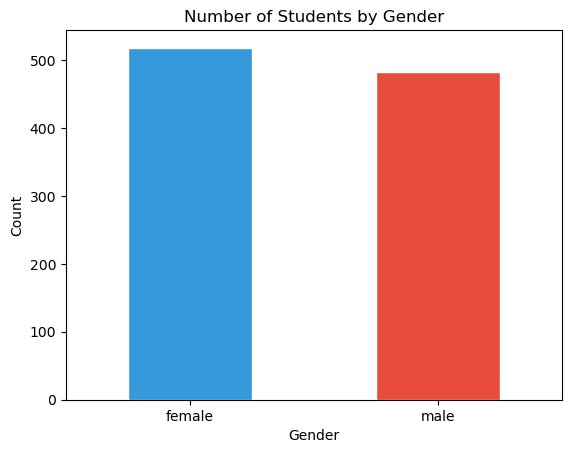

In [6]:
# How many students in each gender?
print(df['gender'].value_counts())
df['gender'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'], edgecolor='white')
plt.title('Number of Students by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

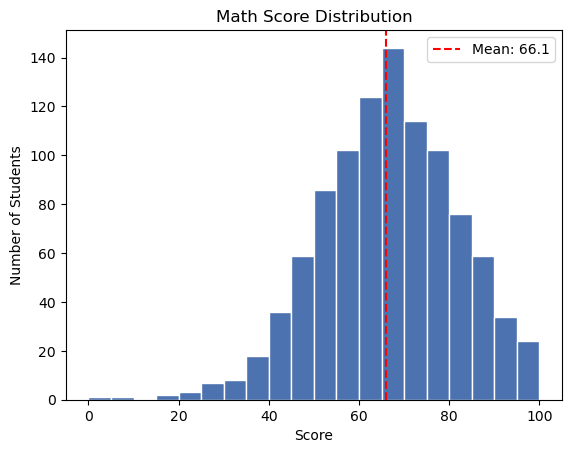

In [7]:
# Distribution of math scores
plt.hist(df['math_score'], bins=20, color='#4C72B0', edgecolor='white')
plt.axvline(df['math_score'].mean(), color='red', linestyle='--', label=f"Mean: {df['math_score'].mean():.1f}")
plt.title('Math Score Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.legend()
plt.show()

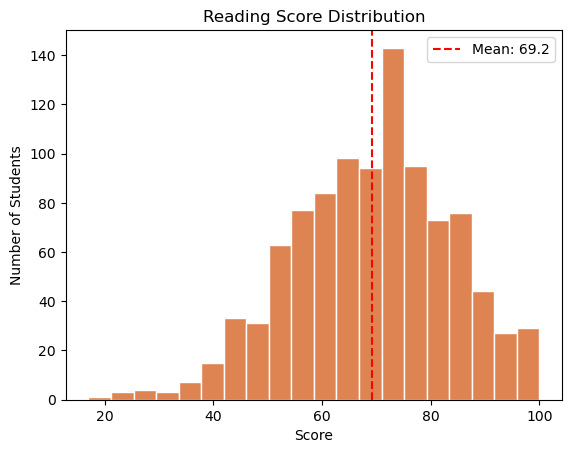

In [8]:
# Distribution of reading scores
plt.hist(df['reading_score'], bins=20, color='#DD8452', edgecolor='white')
plt.axvline(df['reading_score'].mean(), color='red', linestyle='--', label=f"Mean: {df['reading_score'].mean():.1f}")
plt.title('Reading Score Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.legend()
plt.show()

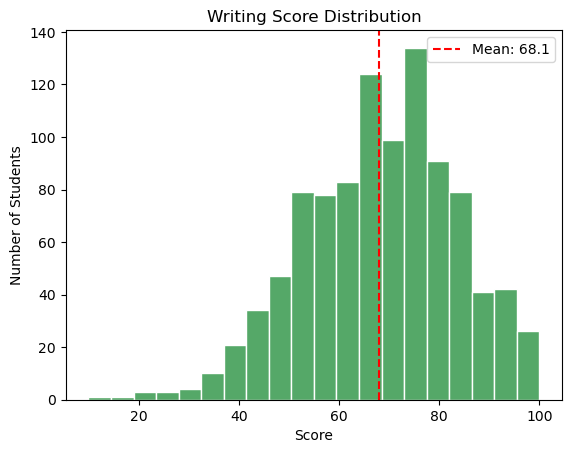

In [9]:
# Distribution of writing scores
plt.hist(df['writing_score'], bins=20, color='#55A868', edgecolor='white')
plt.axvline(df['writing_score'].mean(), color='red', linestyle='--', label=f"Mean: {df['writing_score'].mean():.1f}")
plt.title('Writing Score Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.legend()
plt.show()

test_preparation_course
completed    69.695531
none         64.077882
Name: math_score, dtype: float64


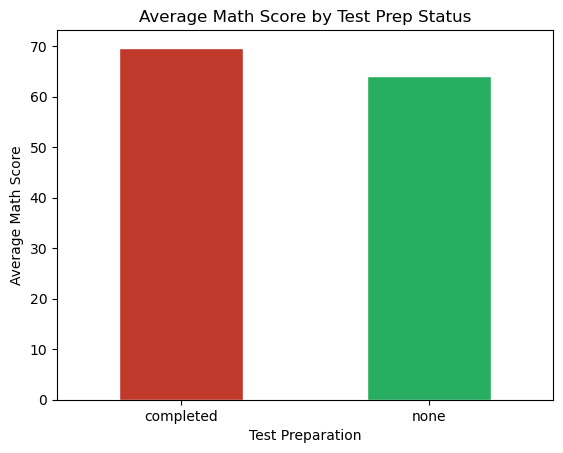

In [10]:
# Does test preparation help?
# Compare average math score for students who completed vs not completed prep
prep_groups = df.groupby('test_preparation_course')['math_score'].mean()
print(prep_groups)

prep_groups.plot(kind='bar', color=['#c0392b', '#27ae60'], edgecolor='white')
plt.title('Average Math Score by Test Prep Status')
plt.xlabel('Test Preparation')
plt.ylabel('Average Math Score')
plt.xticks(rotation=0)
plt.show()

lunch
free/reduced    58.921127
standard        70.034109
Name: math_score, dtype: float64


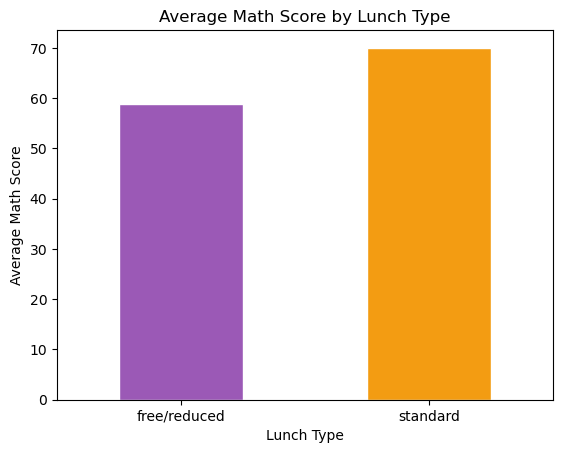

In [11]:
# Does lunch type affect scores?
lunch_groups = df.groupby('lunch')['math_score'].mean()
print(lunch_groups)

lunch_groups.plot(kind='bar', color=['#9b59b6', '#f39c12'], edgecolor='white')
plt.title('Average Math Score by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Average Math Score')
plt.xticks(rotation=0)
plt.show()

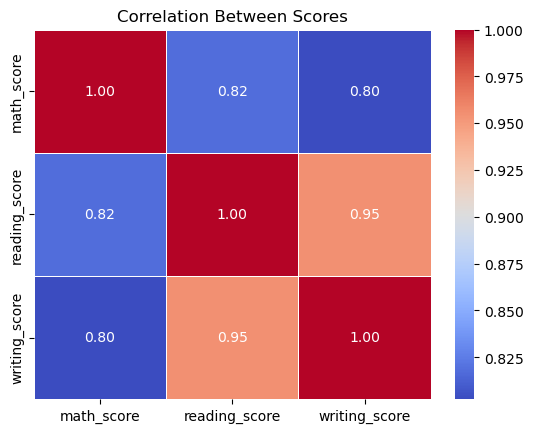

In [12]:
# Correlation between the three scores
score_cols = ['math_score', 'reading_score', 'writing_score']
corr = df[score_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Scores')
plt.show()

---
## 3. Feature Engineering

In [13]:
# Create new useful columns
df['average_score'] = df[score_cols].mean(axis=1)   # Average of all 3 scores
df['total_score']   = df[score_cols].sum(axis=1)    # Total score
df['score_std']     = df[score_cols].std(axis=1)    # How consistent is the student

# Target label: at_risk = 1 if average score is below 60
df['at_risk'] = (df['average_score'] < 60).astype(int)

print("At-Risk Count:")
print(df['at_risk'].value_counts().rename({0: 'Not At Risk', 1: 'At Risk'}))

df[['average_score', 'total_score', 'score_std', 'at_risk']].head()

At-Risk Count:
at_risk
Not At Risk    715
At Risk        285
Name: count, dtype: int64


,average_score,total_score,score_std,at_risk
0,72.666667,218,1.154701,0
1,82.333333,247,11.590226,0
2,92.666667,278,2.516611,0
3,49.333333,148,6.806859,1
4,76.333333,229,1.527525,0


In [14]:
# Encode categorical columns (convert text to numbers)
cat_cols = ['gender', 'race_ethnicity', 'parental_level_of_education',
            'lunch', 'test_preparation_course']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded = df_encoded.astype({col: float for col in df_encoded.select_dtypes('bool').columns})

print(f"Total columns after encoding: {df_encoded.shape[1]}")

Total columns after encoding: 19


---
## 4. Supervised Learning — Random Forest Classifier

> **Goal:** Predict whether a student is at risk using demographic info only (no exam scores as input).

In [15]:
# Define features (X) and target (y)
drop_cols = ['math_score', 'reading_score', 'writing_score',
             'total_score', 'average_score', 'score_std', 'at_risk']

X = df_encoded.drop(columns=drop_cols).astype(float)
y = df_encoded['at_risk']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 800
Test samples:     200


In [16]:
# Train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))

Classification Report:
              precision    recall  f1-score   support

 Not At Risk       0.76      0.95      0.84       143
     At Risk       0.67      0.25      0.36        57

    accuracy                           0.75       200
   macro avg       0.71      0.60      0.60       200
weighted avg       0.73      0.75      0.71       200



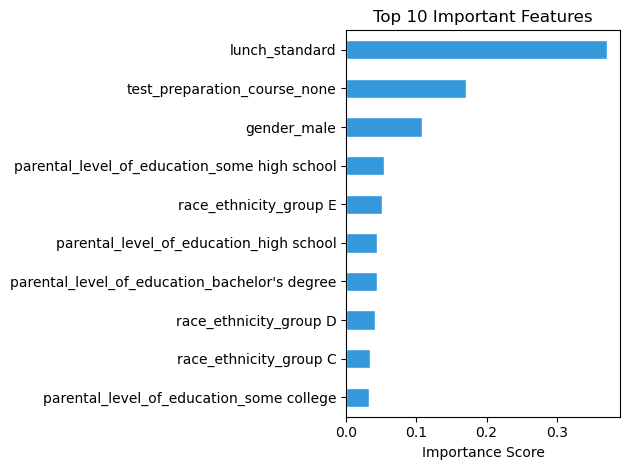

In [17]:
# Which features matter the most?
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

top10.sort_values().plot(kind='barh', color='#3498db', edgecolor='white')
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 5. Unsupervised Learning — K-Means Clustering

> **Goal:** Group students by score patterns to find natural behavior types.

In [18]:
# Use the three score columns for clustering
X_clust = df[['math_score', 'reading_score', 'writing_score']].copy()

# Scale the data — important for K-Means
scaler = StandardScaler()
X_clust_sc = scaler.fit_transform(X_clust)

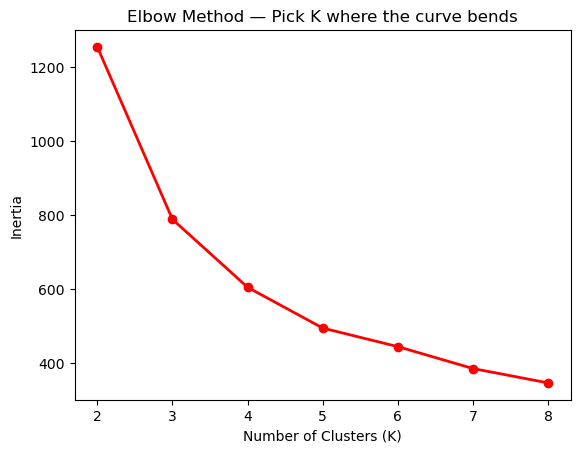

In [19]:
# Elbow method to find the best number of clusters
inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_clust_sc)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, 'ro-', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Pick K where the curve bends')
plt.show()

In [20]:
# Fit K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(X_clust_sc)

print("Students per cluster:")
print(df['cluster'].value_counts().sort_index())

Students per cluster:
cluster
0    299
1    159
2    356
3    186
Name: count, dtype: int64


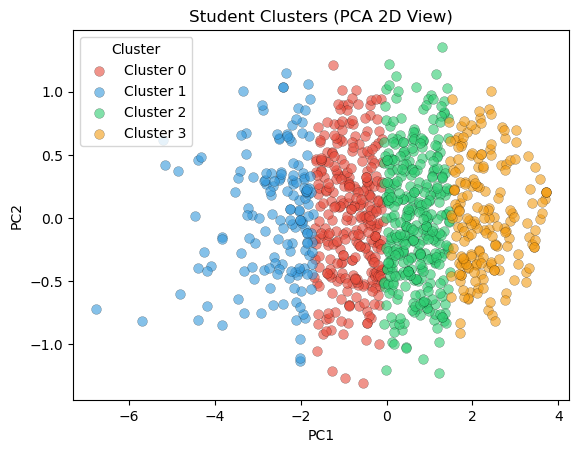

In [21]:
# Use PCA to reduce to 2D so we can plot the clusters
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_clust_sc)

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for c in range(4):
    mask = df['cluster'] == c
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=f'Cluster {c}', alpha=0.6, s=50,
                color=colors[c], edgecolors='k', linewidths=0.2)

plt.title('Student Clusters (PCA 2D View)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

In [22]:
# Profile each cluster — what are their average scores?
profile = df.groupby('cluster')[['math_score', 'reading_score', 'writing_score', 'average_score']].mean().round(1)
print("Cluster Profiles (Average Scores):")
print(profile)

Cluster Profiles (Average Scores):
         math_score  reading_score  writing_score  average_score
cluster                                                         
0              59.2           61.9           60.9           60.7
1              44.5           47.0           44.6           45.4
2              71.4           74.9           74.0           73.4
3              85.5           88.8           88.2           87.5


---
## 6. Summary

| Section | Method | Key Finding |
|---|---|---|
| EDA | Plots & groupby | Test prep and lunch type clearly affect scores |
| Feature Engineering | Domain logic | Created at-risk label, total & average score |
| Supervised | Random Forest | Predicts at-risk students from demographic info |
| Unsupervised | K-Means | 4 natural student groups with different score levels |

---
*Dataset: Students Performance in Exams — Kaggle*